/usr/local/lib/python3.12/dist-packages/huggingface_hub/utils/_auth.py:94: UserWarning: 
The secret `HF_TOKEN` does not exist in your Colab secrets.
To authenticate with the Hugging Face Hub, create a token in your settings tab (https://huggingface.co/settings/tokens), set it as secret in your Google Colab and restart your session.
You will be able to reuse this secret in all of your notebooks.
Please note that authentication is recommended but still optional to access public models or datasets.
  warnings.warn(


modules.json:   0%|          | 0.00/349 [00:00<?, ?B/s]

config_sentence_transformers.json:   0%|          | 0.00/116 [00:00<?, ?B/s]

README.md: 0.00B [00:00, ?B/s]

sentence_bert_config.json:   0%|          | 0.00/53.0 [00:00<?, ?B/s]

...

tokenizer_config.json:   0%|          | 0.00/350 [00:00<?, ?B/s]

vocab.txt: 0.00B [00:00, ?B/s]

tokenizer.json: 0.00B [00:00, ?B/s]

special_tokens_map.json:   0%|          | 0.00/112 [00:00<?, ?B/s]

config.json:   0%|          | 0.00/190 [00:00<?, ?B/s]

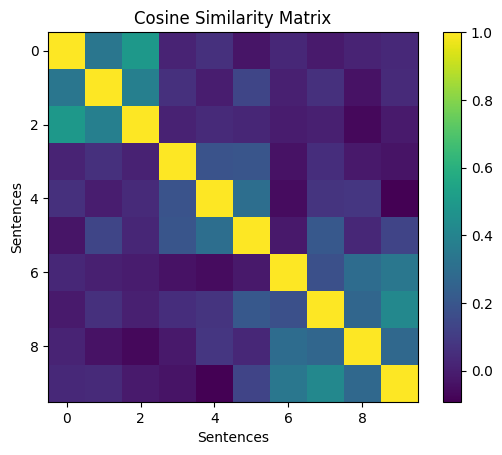

Query: The bowler took three wickets in one over

Top 2 most similar sentences:

He hit a massive six over the bowler's head to win the game. --> Similarity Score: 0.6486
Virat Kohli scored a magnificent century in the final match. --> Similarity Score: 0.4388


In [1]:
# Install required library
!pip install sentence-transformers

# Import libraries
from sentence_transformers import SentenceTransformer, util
import matplotlib.pyplot as plt
import numpy as np

# 1. Create 10 sentences (3 topics)
sentences = [
    # Cricket
    "Virat Kohli scored a magnificent century in the final match.",
    "The pitch is spinning a lot, making it difficult for the batsmen.",
    "He hit a massive six over the bowler's head to win the game.",

    # Cooking
    "You need to chop the onions finely before sautéing them in olive oil.",
    "Bake the cake at 350 degrees for about 45 minutes until golden brown.",
    "Adding a pinch of salt brings out the sweetness in the chocolate chip cookies.",

    # Cybersecurity
    "A strong firewall is essential to protect your internal network from hackers.",
    "Phishing emails try to trick users into revealing their passwords.",
    "We need to encrypt the database to prevent unauthorized access to customer data.",
    "Two-factor authentication adds an extra layer of security to your online accounts."
]

# 2. Generate embeddings
model = SentenceTransformer('all-MiniLM-L6-v2')
embeddings = model.encode(sentences)

# 3. Cosine similarity matrix
cosine_scores = util.cos_sim(embeddings, embeddings).numpy()

# 4. Plot heatmap using matplotlib
plt.figure()
plt.imshow(cosine_scores)
plt.colorbar()
plt.title("Cosine Similarity Matrix")
plt.xlabel("Sentences")
plt.ylabel("Sentences")
plt.show()

# 5. Query sentence
query = "The bowler took three wickets in one over"
query_embedding = model.encode(query)

# 6. Find top 2 similar sentences
search_results = util.semantic_search(query_embedding, embeddings, top_k=2)

print("Query:", query)
print("\nTop 2 most similar sentences:\n")

for result in search_results[0]:
    idx = result['corpus_id']
    score = result['score']
    print(f"{sentences[idx]} --> Similarity Score: {score:.4f}")